# Baseline : deux régressions logistiques (Morpion)

Ce notebook charge le dataset binaire, entraîne **deux** modèles `LogisticRegression` (cibles `x_wins` et `is_draw`), puis compare leurs métriques sur le jeu de test.

In [26]:
# ---------------------------------------------------------------------------
# Imports : pandas pour les données, sklearn pour ML et métriques
# ---------------------------------------------------------------------------
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

In [27]:
# ---------------------------------------------------------------------------
# Constantes : chemin du CSV et noms des colonnes
# ---------------------------------------------------------------------------
DATA_PATH = Path("ressources") / "dataset.csv"

# 9 cases × 2 indicateurs (X et O) = 18 features binaires (ordre c0_x, c0_o, c1_x, …)
FEATURE_COLS = [f"c{i}_{s}" for i in range(9) for s in ("x", "o")]
TARGET_X_WINS = "x_wins"
TARGET_IS_DRAW = "is_draw"

In [28]:
def load_dataset() -> tuple[pd.DataFrame, Path]:
    # Structure de dossier adaptée au notebook
    dataset_path = DATA_PATH

    if not dataset_path.exists():
        raise FileNotFoundError(
            f"Dataset introuvable : {dataset_path}\n"
            "Vérifie que le fichier ressources/test_dataset.csv existe."
        )

    return pd.read_csv(dataset_path), dataset_path


def plot_coefficients(model, title):
    """Visualise les 18 coefficients mappés sur le plateau 3x3"""
    # Les 18 coefs : 9 pour X, 9 pour O
    coefs = model.coef_[0]

    # Découpage des coefficients pour X (indices pairs) et O (indices impairs)
    coefs_x = coefs[0::2].reshape(3, 3)
    coefs_o = coefs[1::2].reshape(3, 3)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=14)

    # Carte pour ci_x (Pions X)
    sns.heatmap(coefs_x, annot=True, cmap='RdBu_r', center=0, ax=ax1)
    ax1.set_title('Influence Pions X (ci_x)')

    # Carte pour ci_o (Pions O)
    sns.heatmap(coefs_o, annot=True, cmap='RdBu_r', center=0, ax=ax2)
    ax2.set_title('Influence Pions O (ci_o)')

    plt.tight_layout()
    plt.show()

In [29]:
# ---------------------------------------------------------------------------
# Fonctions d'évaluation
# ---------------------------------------------------------------------------
def evaluate_binary_classifier(y_true, y_pred, model_name: str) -> None:
    """Affiche accuracy, F1-score et matrice de confusion."""
    print(f"--- Modèle : {model_name} ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("F1-Score :", f1_score(y_true, y_pred, zero_division=0))
    print("Matrice de confusion :")
    print(confusion_matrix(y_true, y_pred))

In [30]:
# ---------------------------------------------------------------------------
# 1) Chargement du dataset
# ---------------------------------------------------------------------------
df, dataset_path = load_dataset()
print(f"Dataset chargé : {dataset_path}")
print(f"Nombre total de lignes : {len(df)}")
df.head()

Dataset chargé : ressources\dataset.csv
Nombre total de lignes : 2423


,c0_x,c0_o,c1_x,c1_o,c2_x,c2_o,c3_x,c3_o,c4_x,c4_o,c5_x,c5_o,c6_x,c6_o,c7_x,c7_o,c8_x,c8_o,x_wins,is_draw
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0
2,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,0,1,0
3,0,0,0,0,0,0,0,1,1,0,0,1,1,0,0,1,1,0,1,0
4,0,0,1,0,0,1,0,1,1,0,0,1,1,0,0,1,1,0,1,0


In [31]:
# ---------------------------------------------------------------------------
# 2) Séparation features / cibles
# ---------------------------------------------------------------------------
X = df[FEATURE_COLS]

y_x_wins = df[TARGET_X_WINS]
y_is_draw = df[TARGET_IS_DRAW]

print(f"Nombre de features : {X.shape[1]}")
print("Colonnes cibles :", [TARGET_X_WINS, TARGET_IS_DRAW])

Nombre de features : 18
Colonnes cibles : ['x_wins', 'is_draw']


In [32]:
# ---------------------------------------------------------------------------
# 3) Train / test split 80 % / 20 %
# ---------------------------------------------------------------------------
X_train, X_test, y_x_train, y_x_test = train_test_split(
    X, y_x_wins, test_size=0.2, random_state=42
)

_, _, y_draw_train, y_draw_test = train_test_split(
    X, y_is_draw, test_size=0.2, random_state=42
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_x_train : {y_x_train.shape}")
print(f"y_draw_train : {y_draw_train.shape}")

X_train : (1938, 18)
X_test  : (485, 18)
y_x_train : (1938,)
y_draw_train : (1938,)


In [33]:
# ---------------------------------------------------------------------------
# 4) Entraînement : deux LogisticRegression indépendantes
# ---------------------------------------------------------------------------
model_x_wins = LogisticRegression(max_iter=1000)
model_is_draw = LogisticRegression(max_iter=1000)

model_x_wins.fit(X_train, y_x_train)
model_is_draw.fit(X_train, y_draw_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
# ---------------------------------------------------------------------------
# 5) Prédictions sur le jeu de test
# ---------------------------------------------------------------------------
pred_x_wins = model_x_wins.predict(X_test)
pred_is_draw = model_is_draw.predict(X_test)

In [35]:
# ---------------------------------------------------------------------------
# 6) Évaluation et comparaison des deux modèles
# ---------------------------------------------------------------------------
print("=== Entraînement Régression Logistique ===")
print(f"Dataset chargé : {dataset_path}")
print(f"Nombre total de lignes : {len(df)}")
print(f"Nombre de features : {X.shape[1]}\n")

evaluate_binary_classifier(y_x_test, pred_x_wins, "x_wins")
print()
evaluate_binary_classifier(y_draw_test, pred_is_draw, "is_draw")

=== Entraînement Régression Logistique ===
Dataset chargé : ressources\dataset.csv
Nombre total de lignes : 2423
Nombre de features : 18

--- Modèle : x_wins ---
Accuracy : 0.7876288659793814
F1-Score : 0.8778173190984578
Matrice de confusion :
[[ 12  88]
 [ 15 370]]

--- Modèle : is_draw ---
Accuracy : 0.8329896907216495
F1-Score : 0.0
Matrice de confusion :
[[404   0]
 [ 81   0]]


In [36]:
# ---------------------------------------------------------------------------
# Résumé comparatif (tableau)
# ---------------------------------------------------------------------------
summary = pd.DataFrame(
    {
        "Modèle": ["x_wins", "is_draw"],
        "Accuracy": [
            accuracy_score(y_x_test, pred_x_wins),
            accuracy_score(y_draw_test, pred_is_draw),
        ],
        "F1-score": [
            f1_score(y_x_test, pred_x_wins, zero_division=0),
            f1_score(y_draw_test, pred_is_draw, zero_division=0),
        ],
    }
)
summary

,Modèle,Accuracy,F1-score
0,x_wins,0.787629,0.877817
1,is_draw,0.832990,0.000000


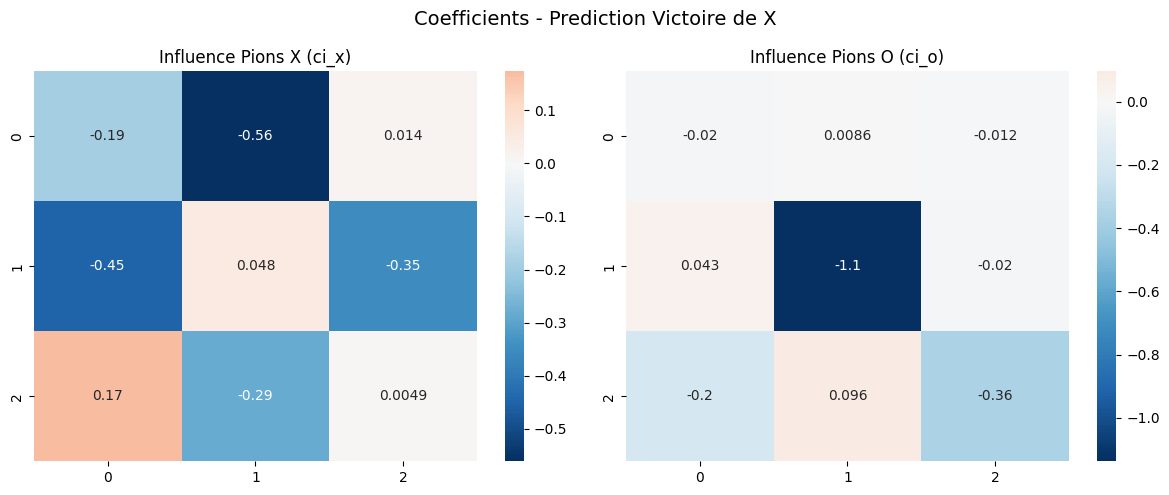

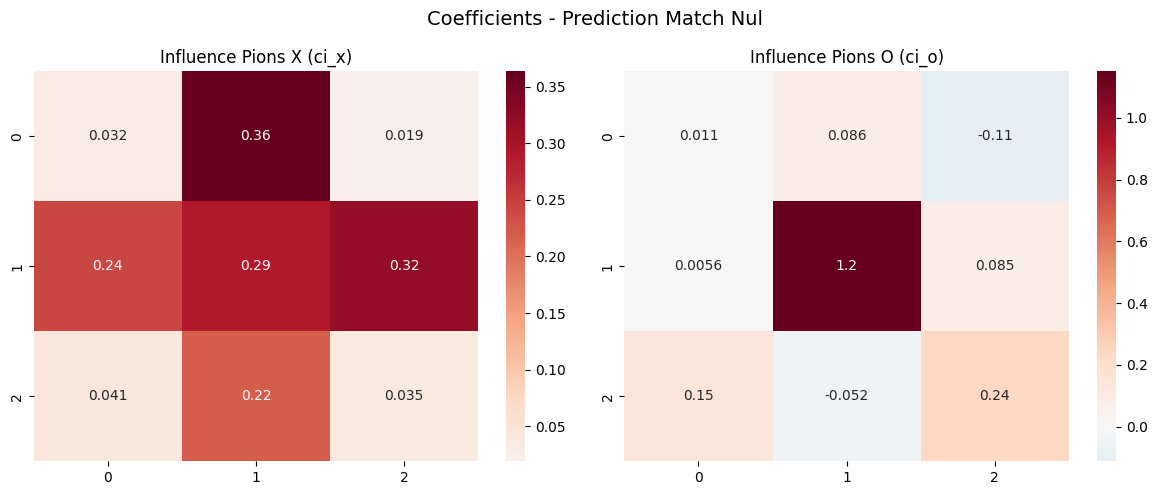

In [37]:
# ---------------------------------------------------------------------------
# 7) Analyse des coefficients
# ---------------------------------------------------------------------------
plot_coefficients(model_x_wins, "Coefficients - Prediction Victoire de X")
plot_coefficients(model_is_draw, "Coefficients - Prediction Match Nul")